In [1]:
import pandas as pd
import matplotlib.pyplot as plt

market = pd.read_csv("../backtesting/market_backtest_v3.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

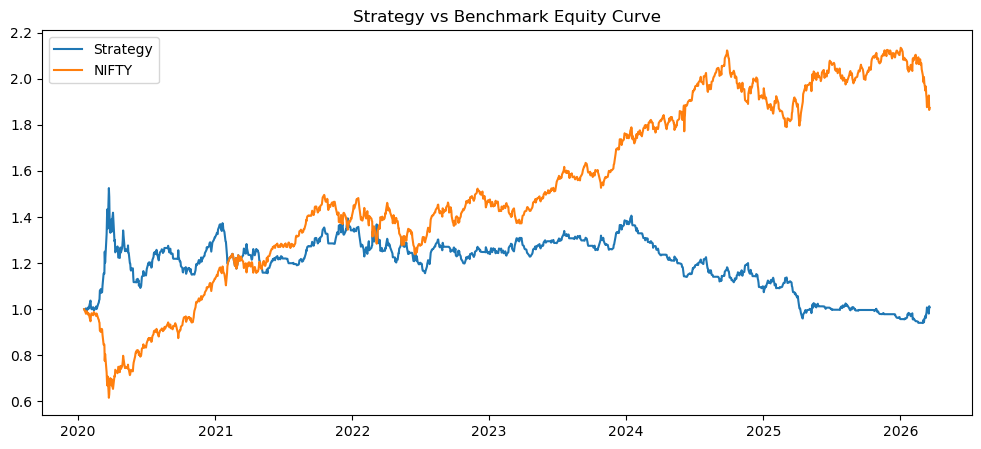

In [2]:
market["strategy_equity"] = (1 + market["strategy_ret_v2"]).cumprod()
market["benchmark_equity"] = (1 + market["nifty_ret"]).cumprod()

market["strategy_equity"] = market["strategy_equity"] / market["strategy_equity"].iloc[0]
market["benchmark_equity"] = market["benchmark_equity"] / market["benchmark_equity"].iloc[0]

plt.figure(figsize=(12,5))

plt.plot(market.index, market["strategy_equity"], label="Strategy")
plt.plot(market.index, market["benchmark_equity"], label="NIFTY")

plt.legend()
plt.title("Strategy vs Benchmark Equity Curve")

plt.show()

In [3]:
market.to_csv("../backtesting/market_backtest_v4.csv")